IMPORT Dữ liệu

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
penguins = pd.read_csv("penguins.csv")

In [4]:
penguins.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE


EDA

In [5]:
#Kiểm tra kích thước
penguins.shape

#Kiểm tra kiểu dữ liệu
penguins.info()

#Kiểm tra dữ liệu thiếu
penguins.isnull().sum()

#Thống kê dữ liệu
penguins.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,214.014620,4201.754386
std,5.459584,1.974793,260.558057,801.954536
min,32.100000,13.100000,-132.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.750000,4750.000000
max,59.600000,21.500000,5000.000000,6300.000000


Tiền xử lý dữ liệu

In [6]:
#Xóa dữ liệu thiếu
penguins = penguins.dropna()

#Mã hóa dữ liệu
encoder = LabelEncoder()

for col in penguins.columns:

    if penguins[col].dtype == "object":

        penguins[col] = encoder.fit_transform(
            penguins[col]
        )

#Kiểm tra dữ liệu sau xử lý
penguins.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,2
1,39.5,17.4,186.0,3800.0,1
2,40.3,18.0,195.0,3250.0,1
4,36.7,19.3,193.0,3450.0,1
5,39.3,20.6,190.0,3650.0,2


Xây dựng mô hình Agglomerative Clustering

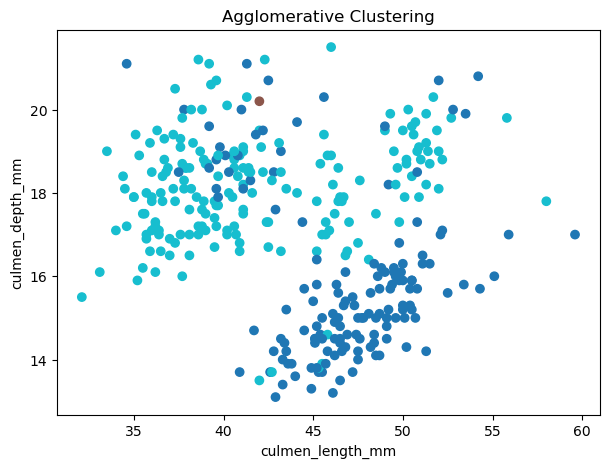

In [7]:
#Khởi tạo mô hình
ac = AgglomerativeClustering(

    n_clusters=3,

    linkage="average"

)

#Huấn luyện mô hình
ac_clusters = ac.fit_predict(penguins)

#Trực quan kết quả
plt.figure(figsize=(7,5))

plt.scatter(

    penguins.iloc[:,0],

    penguins.iloc[:,1],

    c=ac_clusters,

    cmap="tab10"

)

plt.title("Agglomerative Clustering")

plt.xlabel(penguins.columns[0])

plt.ylabel(penguins.columns[1])

plt.show()

Xây dựng mô hình K-Means

d:\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


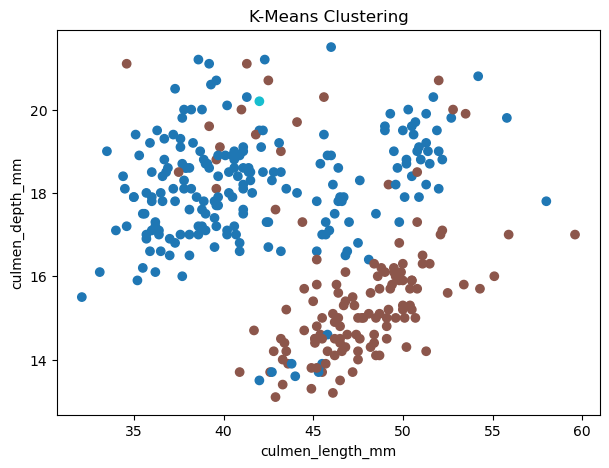

In [8]:
#Khởi tạo mô hình
km = KMeans(

    n_clusters=3,

    random_state=42

)

#Huấn luyện mô hình
km_clusters = km.fit_predict(penguins)

#Trực quan kết quả
plt.figure(figsize=(7,5))

plt.scatter(

    penguins.iloc[:,0],

    penguins.iloc[:,1],

    c=km_clusters,

    cmap="tab10"

)

plt.title("K-Means Clustering")

plt.xlabel(penguins.columns[0])

plt.ylabel(penguins.columns[1])

plt.show()

Đánh giá và so sánh hai mô hình

In [9]:
#Tính Silhouette Score
print("Silhouette Scores\n")

print(

    "Agglomerative Clustering:",

    silhouette_score(

        penguins,

        ac_clusters

    )

)

print(

    "K-Means Clustering:",

    silhouette_score(

        penguins,

        km_clusters

    )

)

Silhouette Scores

Agglomerative Clustering: 0.6203284772056977
K-Means Clustering: 0.6287589325056987
